In [1]:
import os
import torch
import pacmap
import pickle
import datetime
import importlib
import numpy as np
import pandas as pd
import torch.nn as nn
from PIL import Image
from cellsmap.util import io
from skimage import filters as skfilt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from sklearn import decomposition as skdecomp
import matplotlib.pyplot as plt

from cellsmap.analyses.playground import const, trans, dataset, pipeline, arch, trainer, proc

import ae, ae_eval

In [2]:
ndims = 3
# reducer = pacmap.PaCMAP(3)
reducer = skdecomp.PCA(ndims)

def invert_reducer(reducer, latent_variables):
    if type(reducer) == skdecomp._pca.PCA:
        vecs = reducer.transform(latent_variables)
    else:
        vecs = reducer.transform(latent_variables, lv)
    print(vecs.shape)
    return vecs

In [3]:
def get_latent_variables(model, dataloader):
    model.eval()
    latent_vars = []
    with torch.no_grad():
        for batch_data in dataloader:
            encoder_output = model.encoder(batch_data)
            latent_variables = model.latent_space(encoder_output)
            latent_vars.append(latent_variables)
    return torch.cat(latent_vars, dim=0)

from skimage import io as skio
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
def figure_to_numpy(fig):
    canvas = FigureCanvas(fig)
    canvas.draw()
    buf = canvas.buffer_rgba()
    array = np.asarray(buf)
    return array

In [4]:
now = datetime.datetime.now()
print(now.strftime("%Y-%m-%d %H:%M:%S"))

2024-10-13 19:30:02


In [5]:
importlib.reload(arch)
importlib.reload(dataset)

<module 'cellsmap.analyses.playground.dataset' from '/allen/aics/assay-dev/MicroscopyOtherData/Viana/projects/cellsmap/cellsmap/analyses/playground/dataset.py'>

In [6]:
model_name = "8aea4053"
model = arch.SmallConvAutoencoder(latent_dim=const.N, input_size=const.M, nchannels=3)
model.load_state_dict(torch.load(f".output/{model_name}/weight.pth"))
_ = model.eval()

In [10]:
transform = transforms.Compose([transforms.ToTensor()])
reader = io.load_dataset("20240305_T01_001", channels=["CDH5_Tubulin", "Nuc_Seg"], time_start=0, level=2)
delta_dataset = dataset.ZARRTemporalSignalCenteredDataset(reader=reader, dts=[-5,-1,0,1], transform=transform)
delta_dataset.set_evaluation_mode_on()

Dataset ready!


In [83]:
tracks = [[
[980.976,74.108,365],
[980.976,74.108,366],
[980.976,74.108,367],
[980.976,74.108,368],
[980.976,74.108,369],
[980.976,74.108,370],
[980.976,74.108,371],
[980.976,74.108,372]
]]

Dataset ready!


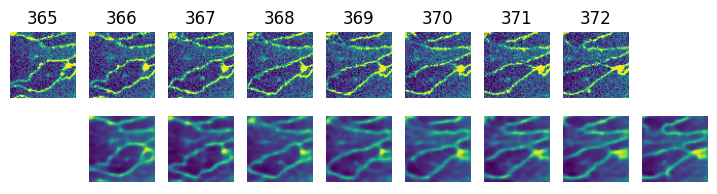

In [84]:
for track in tracks:

    fig, axs = plt.subplots(2, 1+len(track), figsize=(1*(len(track)+1), 2*1))
    
    track = [(int(x/1.5280000), int(y/1.5280000), t) for (x,y,t) in track]
    
    track_dataset = dataset.ZARRTemporalSignalCenteredDatasetFromCoords(reader=reader, dts=[-5,-1,0,1], coords=track, transform=transform)
    track_dataset.set_evaluation_mode_on()
    track_loader = DataLoader(track_dataset, batch_size=len(track), shuffle=False)
    latent_variables = get_latent_variables(model, track_loader)

    recs = model.decoder(latent_variables).detach().numpy().squeeze()

    [ax.axis("off") for ax in axs.flatten()]
    for (x,y,t), (original, _, _, _), rec, ax1, ax2 in zip(track, track_dataset.data, recs, axs[0], axs[1][1:]):
        ax1.imshow(original[:,:,-1])
        ax1.set_title(t)
        ax2.imshow(rec)
    
    break

In [85]:
for tid in range(len(track)-1):
    next_norm = recs[tid].copy()
    next_norm = (next_norm-next_norm.min())/(next_norm.max()-next_norm.min())
    track_dataset.data[tid+1][0][:,:,-1] = next_norm

    track_loader = DataLoader(track_dataset, batch_size=len(track), shuffle=False)
    latent_variables = get_latent_variables(model, track_loader)
    recs = model.decoder(latent_variables).detach().numpy().squeeze()

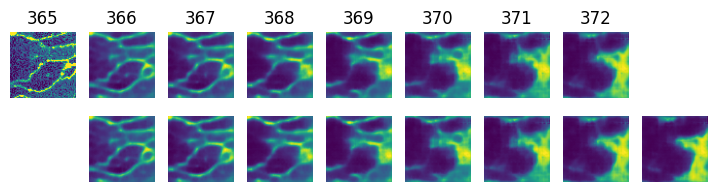

In [86]:
for track in tracks:

    fig, axs = plt.subplots(2, 1+len(track), figsize=(1*(len(track)+1), 2*1))    
    [ax.axis("off") for ax in axs.flatten()]
    for (x,y,t), (original, _, _, _), rec, ax1, ax2 in zip(track, track_dataset.data, recs, axs[0], axs[1][1:]):
        ax1.imshow(original[:,:,-1])
        ax1.set_title(t)
        ax2.imshow(rec)